In [92]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [93]:
DATA_PATH = "./"

# Phân tích file `training_dataset_labeled_period.csv` có khoảng thời gian từ 17/04/2026 - 10/05/2026

## Phân tích tổng quan

In [94]:
df_train = pd.read_csv(DATA_PATH + 'training_dataset_labeled_period.csv')

In [95]:
df_train.head()

,retrieved_at_vn,flight_date,direction,scheduled_time,estimated_time,route_airport,flight_number,status_raw,source_airport,route_airport_std,...,scheduled_month,sin_hour,cos_hour,airline_code,flight_num_only,minutes_to_departure_at_snapshot,is_estimated_missing,visibility_bin,temp_dew_spread,is_low_visibility
0,2026-04-17 22:01:45,2026-04-17,Arrival,22:15,22:23,TP. Hồ Chí Minh (SGN),VN148,Đúng giờ,DN,HO CHI MINH (SGN),...,4,-0.500000,0.866025,VN,148,13.250000,0,Medium,2,0.0
1,2026-04-18 00:10:37,2026-04-18,Departure,07:50,07:50,Hà Nội (HAN),VN158,3-16,DN,HA NOI (HAN),...,4,0.965926,-0.258819,VN,158,459.383333,0,Medium,3,0.0
2,2026-04-18 00:10:37,2026-04-18,Departure,08:50,08:50,Hà Nội (HAN),VN160,3-16,DN,HA NOI (HAN),...,4,0.866025,-0.500000,VN,160,519.383333,0,Medium,3,0.0
3,2026-04-18 00:10:37,2026-04-18,Departure,09:45,09:45,Hà Nội (HAN),VN164,3-16,DN,HA NOI (HAN),...,4,0.707107,-0.707107,VN,164,574.383333,0,Medium,3,0.0
4,2026-04-18 00:10:37,2026-04-18,Departure,11:35,11:35,Hà Nội (HAN),VN166,3-16,DN,HA NOI (HAN),...,4,0.258819,-0.965926,VN,166,684.383333,0,Medium,3,0.0


In [96]:
# Bỏ các cột không có giá trị cho việc EDA
drop_cols = ['retrieved_at_vn', 'report_time_utc', 'report_time_vn', 'raw_metar', 'status_raw', 'route_airport', 'scheduled_time', 
             'estimated_time', 'flight_number']

df_train = df_train.drop(columns=drop_cols)

In [97]:
df_train

,flight_date,direction,source_airport,route_airport_std,status_group,scheduled_dt,estimated_dt,delay_minutes,label_delay,icao_code,...,scheduled_month,sin_hour,cos_hour,airline_code,flight_num_only,minutes_to_departure_at_snapshot,is_estimated_missing,visibility_bin,temp_dew_spread,is_low_visibility
0,2026-04-17,Arrival,DN,HO CHI MINH (SGN),on_time,2026-04-17 22:15:00,2026-04-17 22:23:00,8.0,0,VVDN,...,4,-0.500000,8.660254e-01,VN,148,13.250000,0,Medium,2,0.0
1,2026-04-18,Departure,DN,HA NOI (HAN),other,2026-04-18 07:50:00,2026-04-18 07:50:00,0.0,0,VVDN,...,4,0.965926,-2.588190e-01,VN,158,459.383333,0,Medium,3,0.0
2,2026-04-18,Departure,DN,HA NOI (HAN),other,2026-04-18 08:50:00,2026-04-18 08:50:00,0.0,0,VVDN,...,4,0.866025,-5.000000e-01,VN,160,519.383333,0,Medium,3,0.0
3,2026-04-18,Departure,DN,HA NOI (HAN),other,2026-04-18 09:45:00,2026-04-18 09:45:00,0.0,0,VVDN,...,4,0.707107,-7.071068e-01,VN,164,574.383333,0,Medium,3,0.0
4,2026-04-18,Departure,DN,HA NOI (HAN),other,2026-04-18 11:35:00,2026-04-18 11:35:00,0.0,0,VVDN,...,4,0.258819,-9.659258e-01,VN,166,684.383333,0,Medium,3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3630,2026-04-21,Departure,TSN,HAI PHONG,departed,2026-04-21 17:55:00,NaN,NaN,0,VVTS,...,4,-0.965926,-2.588190e-01,VN,1186,58.250000,1,Medium,11,0.0
3631,2026-04-21,Arrival,TSN,CON DAO,landed,2026-04-21 17:05:00,2026-04-21 16:50:00,-15.0,0,VVTS,...,4,-0.965926,-2.588190e-01,0V,0,8.250000,0,Medium,11,0.0
3632,2026-04-21,Arrival,TSN,DA NANG,delayed,2026-04-21 18:00:00,2026-04-21 18:20:00,20.0,1,VVTS,...,4,-1.000000,-1.836970e-16,VJ,637,63.250000,0,Medium,11,0.0
3633,2026-04-21,Arrival,TSN,CON DAO,delayed,2026-04-21 17:35:00,2026-04-21 18:15:00,40.0,1,VVTS,...,4,-0.965926,-2.588190e-01,VN,1884,38.250000,0,Medium,11,0.0


### Tổng quan dữ liệu

In [98]:
print(f"Số lượng dòng: {df_train.shape[0]}")
print(f"Số lượng cột: {df_train.shape[1]}")
print(df_train.info())

Số lượng dòng: 3635
Số lượng cột: 30
<class 'pandas.DataFrame'>
RangeIndex: 3635 entries, 0 to 3634
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   flight_date                       3635 non-null   str    
 1   direction                         3635 non-null   str    
 2   source_airport                    3635 non-null   str    
 3   route_airport_std                 3635 non-null   str    
 4   status_group                      3635 non-null   str    
 5   scheduled_dt                      3635 non-null   str    
 6   estimated_dt                      1910 non-null   str    
 7   delay_minutes                     1910 non-null   float64
 8   label_delay                       3635 non-null   int64  
 9   icao_code                         3635 non-null   str    
 10  temperature_c                     3635 non-null   int64  
 11  dew_point_c                       3635 non-

### Giá trị bị thiếu

In [99]:
# Liệt kê các cột có giá trị thiếu và tỷ lệ %
missing = df_train.isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print(pd.DataFrame({'Số lượng': missing, 'Tỷ lệ (%)': (missing/len(df_train)*100).round(2)}))
else:
    print("Không có giá trị thiếu.")

                    Số lượng  Tỷ lệ (%)
estimated_dt            1725      47.46
delay_minutes           1725      47.46
wind_direction_deg      1198      32.96


Thiếu hụt then chốt: `estimated_dt` và `delay_minutes` cùng thiếu đến 47.46%, gây mất mát gần một nửa thông tin về biến mục tiêu và mốc thời gian. Và ta có thể thấy có thể đây là lỗi thu nhập dữ liệu theo đợt hoặc theo nhóm chuyến bay.

Dữ liệu thời tiết khuyết: Cột `wind_direction_deg` bị trống 33%, làm giảm đáng kể độ tin cậy khi phân tích tác động của hướng gió đến việc trễ chuyến.

### Dữ liệu trùng lặp

In [100]:
duplicate_count = df_train.duplicated().sum()
print(f"Số lượng dòng trùng lặp: {duplicate_count}")
if duplicate_count > 0:
    df_train = df_train.drop_duplicates()

Số lượng dòng trùng lặp: 1


### Phân tích các cột Numerical

In [101]:
desc = df_train.describe().T
desc

,count,mean,std,min,25%,50%,75%,max
delay_minutes,1909.0,-0.592457,19.826038,-345.000000,0.000000,0.000000,0.000000e+00,245.000000
label_delay,3634.0,0.014584,0.119899,0.000000,0.000000,0.000000,0.000000e+00,1.000000
temperature_c,3634.0,26.611447,1.167663,21.000000,26.000000,27.000000,2.700000e+01,33.000000
dew_point_c,3634.0,23.464227,1.330769,14.000000,23.000000,23.000000,2.400000e+01,26.000000
wind_direction_deg,2436.0,169.396552,111.624210,0.000000,100.000000,180.000000,2.400000e+02,360.000000
wind_speed_kt,3634.0,2.600715,2.235615,0.000000,1.000000,2.000000,3.000000e+00,13.000000
visibility_miles,3634.0,5.928437,0.319546,1.930000,6.000000,6.000000,6.000000e+00,6.000000
is_wind_variable,3634.0,0.329664,0.470156,0.000000,0.000000,0.000000,1.000000e+00,1.000000
weather_age_minutes,3634.0,12.026857,8.074074,0.050000,3.083333,11.200000,1.850000e+01,29.800000
scheduled_hour,3634.0,14.001926,4.944698,0.000000,10.000000,14.000000,1.800000e+01,23.000000


- Mất cân bằng lớn: Tỷ lệ trễ chuyến (`label_delay`) chỉ chiếm 1.56%, khiến việc dự báo trở nên khó khăn.

- Giá trị ngoại lai (Outliers): delay_minutes vẫn tồn tại giá trị âm bất thường (-345) hoặc dương bất thường (+245) cần được kiểm tra.

- Độ ẩm rất cao: Chênh lệch nhiệt độ và `temp_dew_spread` trung bình chỉ 3.2°C, cho thấy không khí rất ẩm.

- Thời điểm snapshot: Dữ liệu được ghi nhận trung bình trước giờ bay khoảng 13 tiếng.

- Và có một dữ liệu gây nhiễu `flight_num_only`: đây là cột number tách từ số hiệu cho nên ta có thể không để tâm đến giá trị này.

### Phân tích các cột Categorical

In [102]:
categorical_cols = df_train.select_dtypes(include=['object', 'str']).columns
for col in categorical_cols:
    print(f"{col:<18}: {df_train[col].nunique():>4} giá trị khác nhau")

flight_date       :   24 giá trị khác nhau
direction         :    2 giá trị khác nhau
source_airport    :    3 giá trị khác nhau
route_airport_std :   28 giá trị khác nhau
status_group      :    5 giá trị khác nhau
scheduled_dt      : 2606 giá trị khác nhau
estimated_dt      : 1656 giá trị khác nhau
icao_code         :    3 giá trị khác nhau
cloud_cover       :  125 giá trị khác nhau
airline_code      :   10 giá trị khác nhau
visibility_bin    :    2 giá trị khác nhau


1. Nhóm Low Cardinality
- `direction`, `source_airport`, `icao_code` có độ đa dạng thấp -> có thể One-hot Encoding

- `airline_code` là số lượng hãng bay được dùng để thay thế cho `flight_number` số hiệu chuyến bay

2. Nhóm dữ liệu thời gian
- `scheduled_dt`, `estimated_dt` -> Không đưa trực tiếp vào mô hình, sẽ dùng các cột được tách sẵn như `scheduled_hour`. `scheduled_dayofweek` có độ đa dạng thấp và mang tính quy luật hơn.

### Phân tích cột Label

C:\Users\vnviv\AppData\Local\Temp\ipykernel_47216\3213847593.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label_delay', data=df_train, palette='viridis')


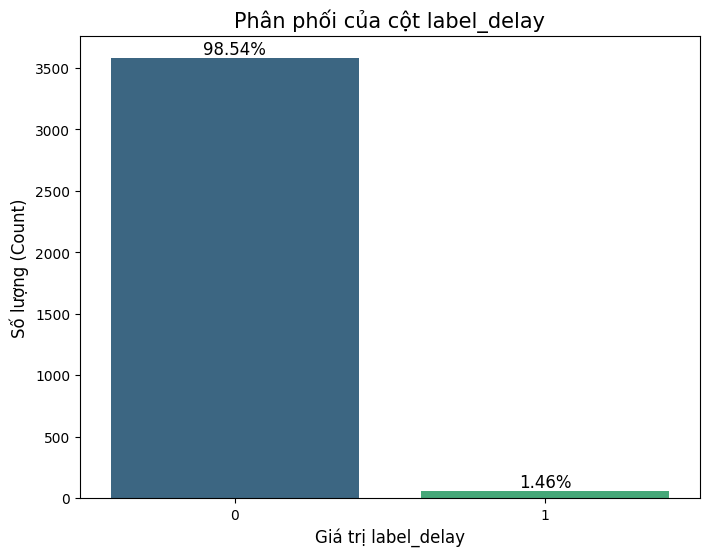

In [103]:
plt.figure(figsize=(8, 6))

# 2. Vẽ biểu đồ countplot (đếm số lượng từng loại)
ax = sns.countplot(x='label_delay', data=df_train, palette='viridis')

# 3. Tính toán phần trăm và hiển thị lên đầu mỗi cột
total = len(df_train['label_delay'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

# 4. Thêm tiêu đề và nhãn
plt.title('Phân phối của cột label_delay', fontsize=15)
plt.xlabel('Giá trị label_delay', fontsize=12)
plt.ylabel('Số lượng (Count)', fontsize=12)

# 5. Hiển thị biểu đồ
plt.show()

$\rightarrow$ Dữ liệu bị mất cân bằng nghiêm trọng, tỉ lệ trễ chỉ có 1.46%

### Kiểm tra tính Logic

In [104]:
print("--- Kiểm tra tính Logic ---")

# 1. Nhiệt độ không thể thấp hơn điểm sương (vật lý)
physics_error = df_train[df_train['temperature_c'] < df_train['dew_point_c']]
print(f"Số dòng lỗi Nhiệt độ < Điểm sương: {len(physics_error)}")

# 2. Kiểm tra những chuyến bay 'đúng giờ' (label 0) nhưng số phút trễ lại quá lớn
logic_error = df_train[(df_train['label_delay'] == 0) & (df_train['delay_minutes'] > 15)]
print(f"Số dòng lỗi Label=0 nhưng trễ > 15p: {len(logic_error)}")

--- Kiểm tra tính Logic ---
Số dòng lỗi Nhiệt độ < Điểm sương: 0
Số dòng lỗi Label=0 nhưng trễ > 15p: 0


## Phân tích Đơn biến

### Phân tích cột `deplay_minutes` của mô hình

--- Phân tích dòng thiếu delay_minutes ---
status_group
on_time     1691
landed        22
departed      12
Name: count, dtype: int64


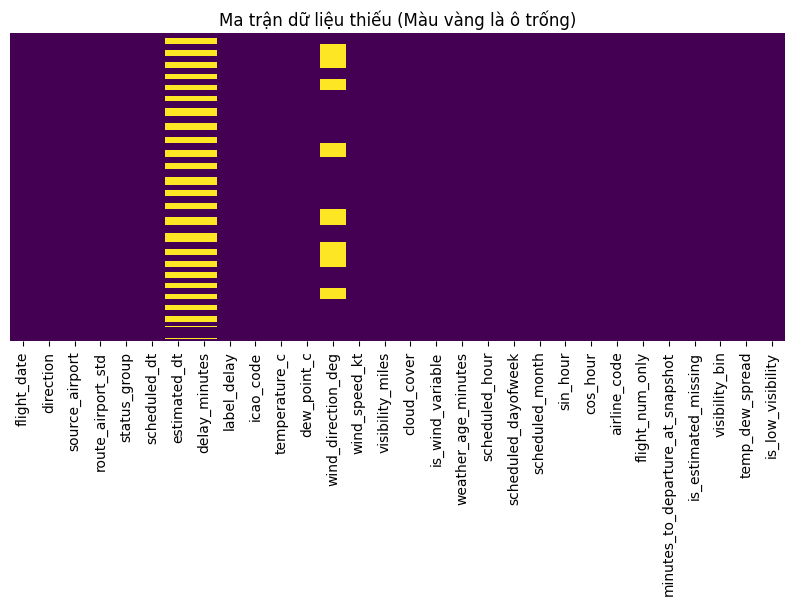

In [105]:
missing_delay = df_train[df_train['delay_minutes'].isnull()]
print("--- Phân tích dòng thiếu delay_minutes ---")
print(missing_delay['status_group'].value_counts())

# Trực quan hóa ma trận dữ liệu thiếu (để xem các cột có thiếu cùng lúc không)
plt.figure(figsize=(10, 4))
sns.heatmap(df_train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Ma trận dữ liệu thiếu (Màu vàng là ô trống)')
plt.show()

Các dòng `deplay_minutes` bị thiếu nhưng đều có `status_group` là `on_time`, `landed` hoặc `departed`  -> Có thể là chưa cập nhật được dữ liệu về các chuyến bay này cho nên bị thiếu `deplay_minutes` ở các dòng này. Không ảnh hưởng quá lớn đến dataset

### Phân tích Phân phối và Độ lệch

Skewness của delay_minutes: -7.18
Skewness của temperature_c: 0.92
Skewness của wind_speed_kt: 1.59
Skewness của visibility_miles: -6.01
Skewness của scheduled_hour: -0.01


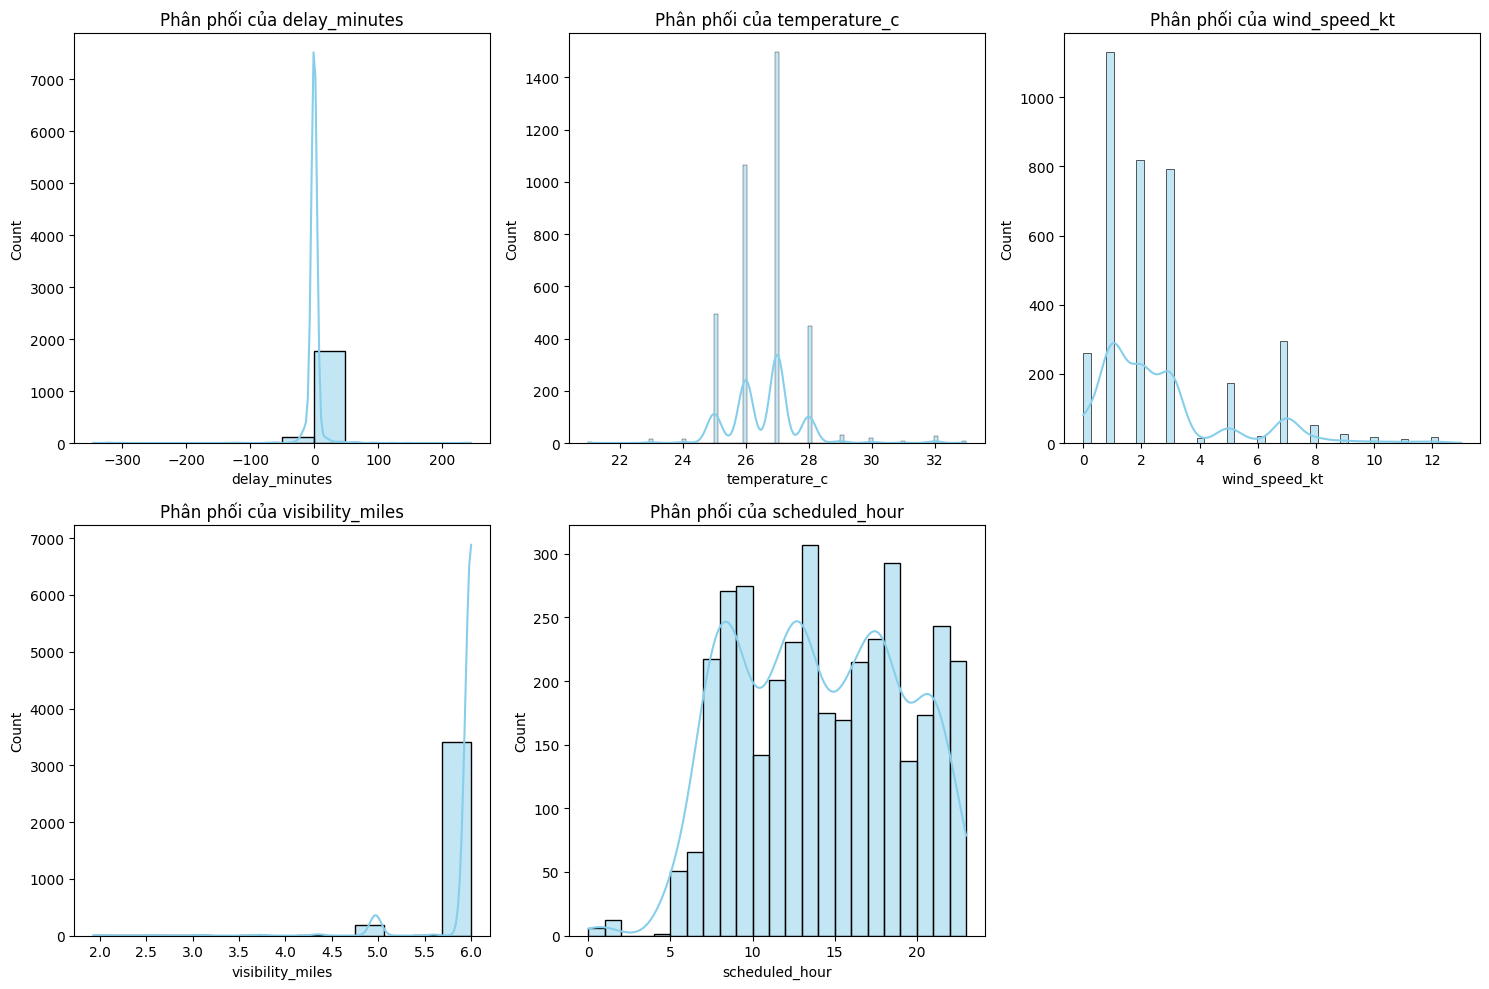

In [106]:
# Danh sách các cột số cần kiểm tra
num_cols = ['delay_minutes', 'temperature_c', 'wind_speed_kt', 'visibility_miles', 'scheduled_hour']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_train[col], kde=True, color='skyblue')
    plt.title(f'Phân phối của {col}')
    # Tính độ lệch (Skewness)
    print(f"Skewness của {col}: {df_train[col].skew():.2f}")

plt.tight_layout()
plt.show()

`delay_minutes`: Lệch trái cực nghiêm trọng. Đuôi bên trái rất dài, chủ yếu do các giá trị âm bất thường (như -345 phút) kéo lệch phân phối.

`visibility_miles`: Lệch trái rất mạnh. Điều này dễ hiểu vì đa số các chuyến bay có tầm nhìn tối đa (6 dặm), chỉ một số ít trường hợp tầm nhìn thấp mới kéo đuôi về bên trái.

`wind_speed_kt`: Lệch phải rõ rệt. Phần lớn thời gian là gió nhẹ (0-3 knot), nhưng có một vài trường hợp gió mạnh (lên tới 13 knot) tạo thành đuôi dài bên phải.

`temperature_c`: Lệch phải vừa phải. Đa số nhiệt độ tập trung quanh mức 26-27°C, nhưng có một số giá trị cao hơn (33-36°C) làm phân phối hơi lệch về bên phải.

`scheduled_hour`: Gần như đối xứng hoàn hảo. Chỉ số này sát mức 0, cho thấy các chuyến bay được phân bổ rất đều và cân bằng qua các khung giờ trong ngày.

## Phân tích Đa biến

### Phân tích tương quan

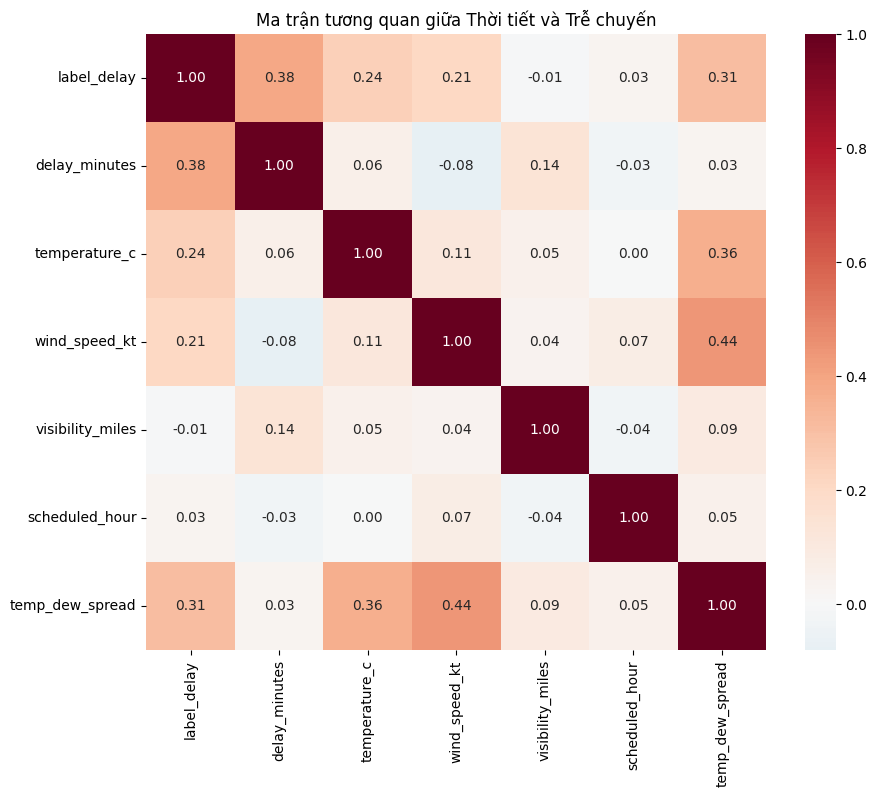

In [107]:
# Chọn các cột số quan trọng
corr_cols = ['label_delay', 'delay_minutes', 'temperature_c', 'wind_speed_kt', 
             'visibility_miles', 'scheduled_hour', 'temp_dew_spread']

plt.figure(figsize=(10, 8))
correlation_matrix = df_train[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Ma trận tương quan giữa Thời tiết và Trễ chuyến')
plt.show()

**Nhận xét:**
- Tương quan nội bộ mục tiêu: label_delay và delay_minutes có tương quan thuận 0.38, cho thấy việc có trễ hay không và số phút trễ có liên quan mật thiết nhưng không phải là tuyệt đối.

- Biến thời tiết ảnh hưởng nhất: Chênh lệch nhiệt độ - điểm sương (`temp_dew_spread`) có tương quan cao nhất với việc trễ chuyến (0.24), theo sau là nhiệt độ (0.21).

- Nghịch lý về gió: Tốc độ gió (wind_speed_kt) có tương quan thuận `label_delay` (0.21) nhưng lại có tương quan nhẹ (0.06) với số phút trễ thực tế.

- Biến ít tác động: Giờ bay (scheduled_hour) và tầm nhìn (visibility_miles) có hệ số gần bằng 0, cho thấy chúng gần như không có mối quan hệ tuyến tính với việc trễ chuyến trong dữ liệu này.

- Hiện tượng đa cộng tuyến: `temp_dew_spread` có tương quan khá mạnh với `temperature_c` (0.36) và wind_speed_kt (0.44), nên cân nhắc khi chọn cả ba làm đặc trưng cho mô hình.

### Các Phát hiện Bất thường

C:\Users\vnviv\AppData\Local\Temp\ipykernel_47216\3497176978.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='airline_code', y='delay_minutes', data=df_train, palette='Set3')


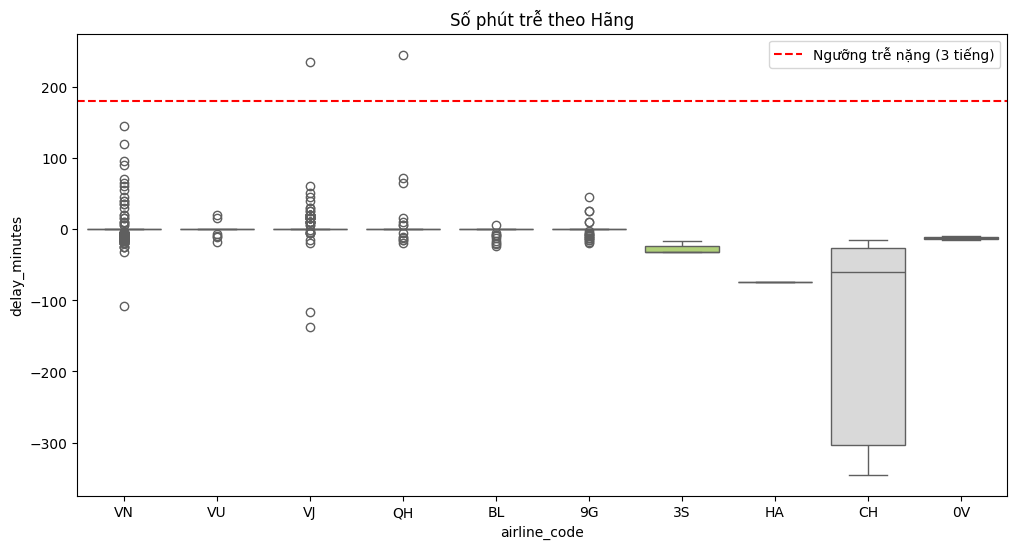

Top 5 chuyến bay trễ nhất
|      | airline_code   |   flight_num_only |   delay_minutes | status_group   |
|-----:|:---------------|------------------:|----------------:|:---------------|
|  263 | QH             |               150 |             245 | on_time        |
| 3438 | VJ             |               509 |             235 | delayed        |
| 3616 | VN             |               212 |             145 | other          |
| 3441 | VN             |              1806 |             120 | delayed        |
| 2585 | VN             |              7193 |              95 | on_time        |
| 3418 | VN             |              7621 |              90 | delayed        |
| 2751 | QH             |               150 |              72 | on_time        |
| 3499 | VN             |               173 |              70 | delayed        |
| 2403 | QH             |               147 |              65 | on_time        |
| 2468 | VN             |              7176 |              65 | other          |


In [108]:
plt.figure(figsize=(12, 6))

# Đổi hue thành x để hiện nhãn dưới trục hoành
sns.boxplot(x='airline_code', y='delay_minutes', data=df_train, palette='Set3')

plt.axhline(y=180, color='red', linestyle='--', label='Ngưỡng trễ nặng (3 tiếng)')
plt.title('Số phút trễ theo Hãng')
plt.legend()
plt.show()

# Lọc ra danh sách 5 chuyến bay trễ "kinh khủng" nhất để inspect
outliers_top = df_train.nlargest(10, 'delay_minutes')[['airline_code', 'flight_num_only','delay_minutes', 'status_group']]
print("Top 5 chuyến bay trễ nhất")
print(outliers_top.to_markdown())

**Nhận xét từ biểu đồ Boxplot**
- Độ tập trung cao ở mức 0: Hầu hết các hãng lớn như VN, VU, VJ, QH, BL đều có hộp bị nén bẹt ở mức 0. Điều này cho thấy đại đa số các chuyến bay của các hãng này đều đúng giờ (cũng có thể hiểu cho tỉ lệ trễ chỉ chiếm hơn 1%).

- Vấn đề dữ liệu âm: Các hãng như CH, HA, 3S có phần boxplot nằm hoàn toàn dưới mức 0. Đặc biệt là hãng CH có dải dữ liệu kéo dài xuống tận -350 phút. Đây là các giá trị ngoại lai cực kỳ vô lý (không thể bay sớm 6 tiếng), cần lọc bỏ hoặc xử lý lại đống dữ liệu này trước khi đưa vào mô hình.

- Các Outliers: Chỉ có QH và VJ là có các điểm dữ liệu vượt qua "Ngưỡng trễ nặng" (180 phút).

**Các chuyến bay có thời tiết tốt nhưng bị label là trễ chuyến**

In [109]:
# Lọc các chuyến trễ nặng trong điều kiện thời tiết tốt
operational_anomalies = df_train[
    (df_train['label_delay'] == 1) & 
    (df_train['visibility_miles'] >= 6) & 
    (df_train['wind_speed_kt'] < 10)
]
print(f"Số lượng bất thường vận hành: {len(operational_anomalies)}")

Số lượng bất thường vận hành: 39


In [110]:
print(operational_anomalies['airline_code'].value_counts())

airline_code
VJ    17
VN    14
QH     4
9G     2
VU     2
Name: count, dtype: int64


In [111]:
# Kiểm tra ngày và giờ của các ca bất thường
print(operational_anomalies[['flight_date', 'scheduled_hour', 'delay_minutes', 'label_delay']])

     flight_date  scheduled_hour  delay_minutes  label_delay
263   2026-04-19               7          245.0            1
1923  2026-04-30               1           60.0            1
2157  2026-05-02               6           15.0            1
2403  2026-05-03              17           65.0            1
2585  2026-05-04               1           95.0            1
2751  2026-05-05               7           72.0            1
2775  2026-05-06               7           15.0            1
3032  2026-05-08               9           15.0            1
3061  2026-05-08               9           15.0            1
3105  2026-05-08              12           20.0            1
3418  2026-04-19              17           90.0            1
3438  2026-04-24              13          235.0            1
3441  2026-04-24              19          120.0            1
3445  2026-04-25              11           15.0            1
3465  2026-04-27              16           50.0            1
3466  2026-04-27        

**Nhận xét:** Ta thấy ở điều kiện thời tiết thuận lời như `visibility_miles >= 6` và `wind_speed_kt <=10` thì có đến 39 trường hợp chuyến bay bị đánh dấu là trễ

$\rightarrow$ Không thể nhận định là các yếu tố thời tiết là nhân tố duy nhất dẫn đến việc các chuyến bay bị trễ mà còn do các cơ sở hạ tầng, việc trễ chuyến dây chuyền làm cho toàn bộ hệ thống bị quá tải.

### Phân tích xu hướng theo thời gian

**Tỉ lệ trễ theo các ngày thực tế**

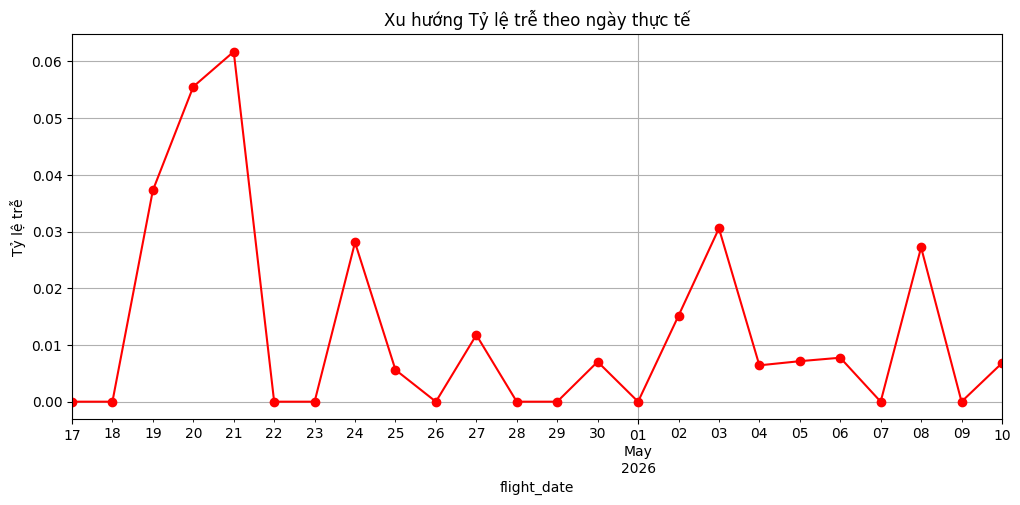

In [112]:
# Chuyển flight_date về datetime và vẽ trend theo ngày
df_train['flight_date'] = pd.to_datetime(df_train['flight_date'])
daily_trend = df_train.groupby('flight_date')['label_delay'].mean()

plt.figure(figsize=(12, 5))
daily_trend.plot(marker='o', color='red')
plt.title('Xu hướng Tỷ lệ trễ theo ngày thực tế')
plt.ylabel('Tỷ lệ trễ')
plt.grid(True)

**Tỉ lệ trễ theo các giờ trong ngày**

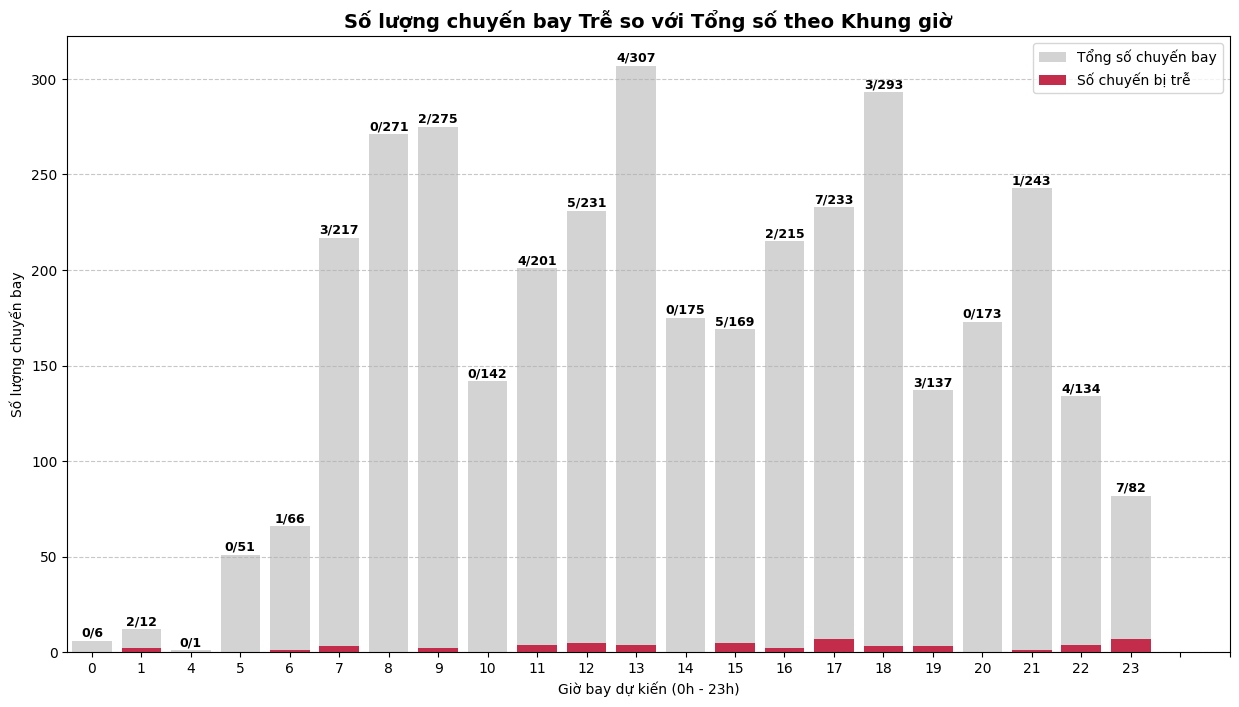

In [113]:
hourly_counts = df_train.groupby(['scheduled_hour', 'label_delay']).size().unstack(fill_value=0)
hourly_counts.columns = ['Đúng giờ', 'Trễ']
hourly_counts['Tổng số'] = hourly_counts['Đúng giờ'] + hourly_counts['Trễ']

# 2. Vẽ biểu đồ
plt.figure(figsize=(15, 8))

# Vẽ cột "Tổng số" trước (màu nhạt hơn)
sns.barplot(x=hourly_counts.index, y=hourly_counts['Tổng số'], color='lightgrey', label='Tổng số chuyến bay')

# Vẽ chồng cột "Trễ" lên trên (màu đậm/nổi bật)
sns.barplot(x=hourly_counts.index, y=hourly_counts['Trễ'], color='crimson', label='Số chuyến bị trễ')

# 3. Thêm nhãn số lượng trên đầu mỗi cột để dễ quan sát
for i, total in enumerate(hourly_counts['Tổng số']):
    delay = hourly_counts['Trễ'].iloc[i]
    # Hiển thị: Số trễ / Tổng số
    plt.text(i, total + 0.5, f'{delay}/{total}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Số lượng chuyến bay Trễ so với Tổng số theo Khung giờ', fontsize=14, fontweight='bold')
plt.xlabel('Giờ bay dự kiến (0h - 23h)')
plt.ylabel('Số lượng chuyến bay')
plt.legend()
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

- Tỷ lệ trễ cực thấp trên tổng thể: Nhìn trực quan, số chuyến trễ rất thấp so tổng số chuyến của 1 ngày. Điều này khớp với con số ~1.5% mà chúng ta đã thấy ở các bảng thống kê trước đó.

- Khung giờ "cao điểm" về số lượng: Chuyến bay tập trung dày đặc nhất vào khung giờ 13h (307 chuyến) và 18h (293 chuyến). Tuy nhiên, số lượng chuyến bay lớn không đồng nghĩa với việc tỷ lệ trễ sẽ cao nhất.

- Khung giờ khuya: * 23h: Đây là khung giờ đáng chú ý nhất. Dù chỉ có 82 chuyến bay nhưng có tới 7 chuyến trễ, cao hơn hẳn mức trung bình toàn bộ dữ liệu.

- 1h sáng: Tỷ lệ trễ lên tới 16.7% (2/12 chuyến). Dù mẫu số nhỏ nhưng nó cho thấy xu hướng các chuyến bay muộn dễ bị dồn toa hoặc gặp sự cố dây chuyền từ các khung giờ trước.

**Tỉ lệ trễ theo các ngày trong tuần**

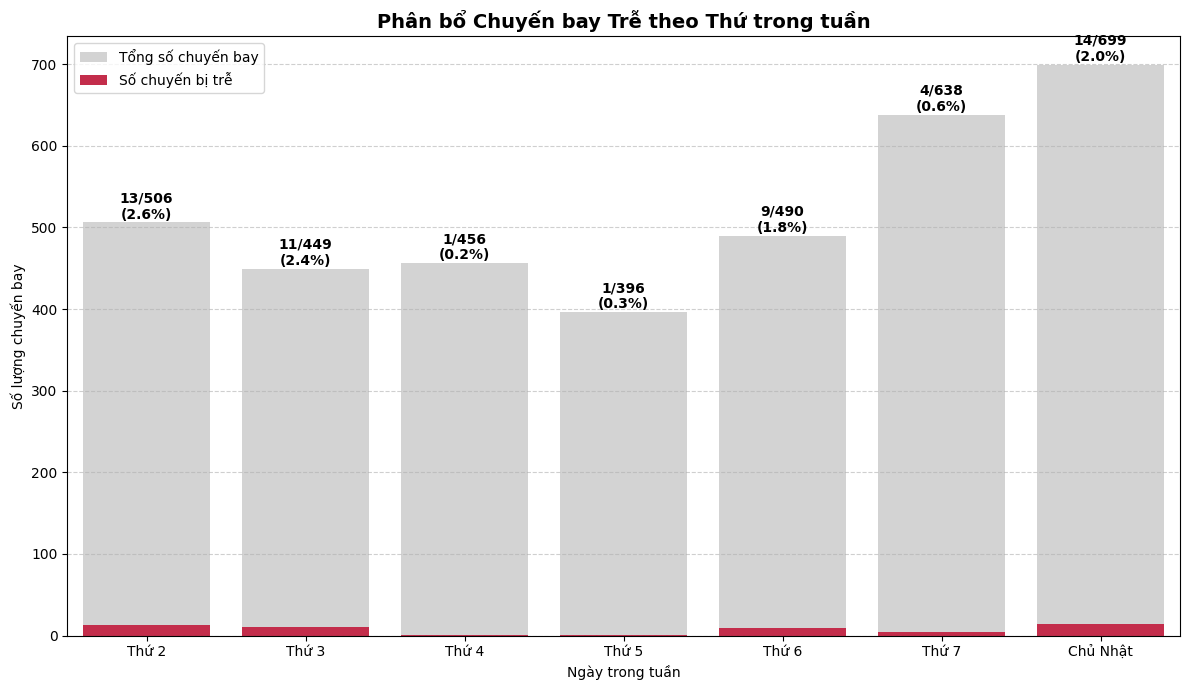

In [114]:
weekly_counts = df_train.groupby(['scheduled_dayofweek', 'label_delay']).size().unstack(fill_value=0)
weekly_counts.columns = ['Đúng giờ', 'Trễ']
weekly_counts['Tổng số'] = weekly_counts['Đúng giờ'] + weekly_counts['Trễ']
weekly_counts = weekly_counts.reindex(range(7), fill_value=0)

day_labels = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật']

# 2. Vẽ biểu đồ
plt.figure(figsize=(12, 7))

# Vẽ cột "Tổng số" (Màu xám nhạt làm nền)
sns.barplot(x=weekly_counts.index, y=weekly_counts['Tổng số'], color='lightgrey', label='Tổng số chuyến bay')

# Vẽ chồng cột "Trễ" (Màu cam hoặc đỏ để nhấn mạnh)
sns.barplot(x=weekly_counts.index, y=weekly_counts['Trễ'], color='crimson', label='Số chuyến bị trễ')

# 3. Thêm nhãn số lượng và Tỷ lệ % trên đầu mỗi cột
for i, total in enumerate(weekly_counts['Tổng số']):
    delay = weekly_counts['Trễ'].iloc[i]
    rate = (delay / total) * 100
    # Hiển thị: Số trễ / Tổng số (Tỷ lệ %)
    plt.text(i, total + 1, f'{delay}/{total}\n({rate:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Phân bổ Chuyến bay Trễ theo Thứ trong tuần', fontsize=14, fontweight='bold')
plt.xlabel('Ngày trong tuần')
plt.ylabel('Số lượng chuyến bay')
plt.xticks(ticks=range(7), labels=day_labels)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

- Đỉnh điểm rủi ro: Thứ 2 và Thứ 3 là hai ngày "nhạy cảm" nhất với tỷ lệ trễ cao nhất tuần (lần lượt là 2.6% và 2.4%). Có thể do bị tồn đọng từ những lượng máy bay rất nhiều từ Chủ nhật khiến cho đế Thứ 2 và Thứ 3 vẫn còn trễ.

- Khoảng thời gian "vàng": Thứ 4 và Thứ 5 là thời điểm bay an tâm nhất, khi tỷ lệ trễ giảm sâu xuống mức gần như bằng không (0.2% - 0.3%).

- Áp lực lưu lượng: Chủ Nhật là ngày bận rộn nhất với gần 700 chuyến bay, kéo theo số lượng ca trễ tuyệt đối cao nhất (14 chuyến).

- Điểm sáng vận hành: Thứ 7 ghi nhận hiệu suất ấn tượng khi gánh lượng bay lớn thứ hai tuần nhưng vẫn kiểm soát tỷ lệ trễ ở mức rất thấp (0.6%).

- Xu hướng hình chữ U: Rủi ro trễ chuyến có xu hướng tập trung vào hai đầu tuần (Thứ 2-3) và cuối tuần (Chủ Nhật), trong khi ổn định hoàn toàn ở giữa tuần.

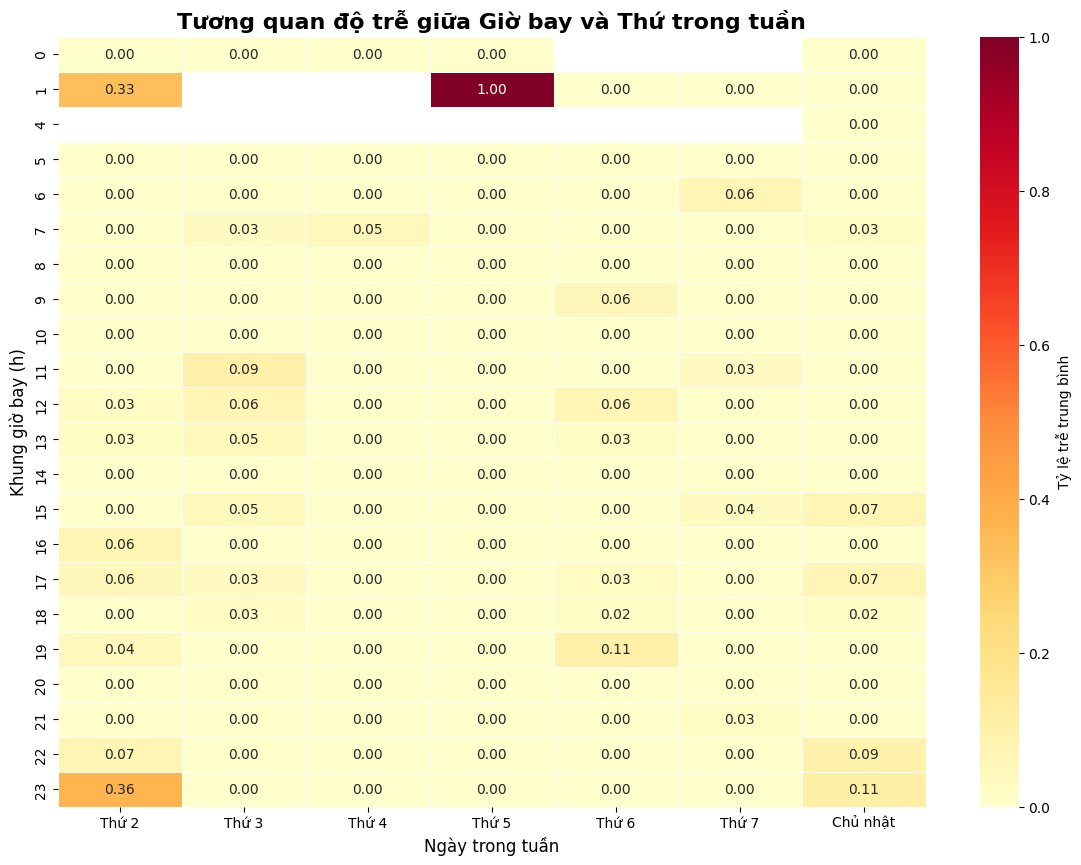

In [115]:
heatmap_data = df_train.groupby(['scheduled_hour', 'scheduled_dayofweek'])['label_delay'].mean().unstack()

day_map = {
    0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 
    3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ nhật'
}

heatmap_data = heatmap_data.rename(columns=day_map)

plt.figure(figsize=(14, 10))

# Vẽ heatmap
sns.heatmap(heatmap_data, 
            annot=True,
            fmt=".2f",
            cmap="YlOrRd",
            linewidths=.5,
            cbar_kws={'label': 'Tỷ lệ trễ trung bình'})

# Thêm tiêu đề và nhãn
plt.title('Tương quan độ trễ giữa Giờ bay và Thứ trong tuần', fontsize=16, fontweight='bold')
plt.xlabel('Ngày trong tuần', fontsize=12)
plt.ylabel('Khung giờ bay (h)', fontsize=12)

plt.show()

- Điểm bất thường: Khung giờ 1h sáng Thứ 5 ghi nhận tỷ lệ trễ tuyệt đối 1.00. Tuy nhiên, dựa trên biểu đồ trước đó (chỉ có 12 chuyến lúc 1h sáng), đây có thể là do cỡ mẫu quá nhỏ nhưng tất cả đều bị trễ, tạo nên khung màu đỏ trên hình.

- Áp lực đêm muộn Thứ 2: Đây là khu vực có độ rủi ro cao nhất trong các ngày thường. Tỷ lệ trễ vọt lên 0.33 (1h sáng) và 0.36 (23h đêm). Có vẻ như các sự cố từ ngày Chủ Nhật hoặc rạng sáng đầu tuần chưa được giải quyết triệt để.

- Hiệu ứng cuối tuần (Chủ Nhật): Tỷ lệ trễ bắt đầu tăng dần từ 15h chiều (0.07) và duy trì đến tận 23h đêm (0.11). Điều này khớp với việc Chủ Nhật có lưu lượng bay lớn nhất, dẫn đến quá tải hệ thống vào cuối ngày.

- Vùng an toàn: Khung giờ từ 8h sáng đến 14h chiều ở hầu hết các ngày (đặc biệt là Thứ 4 và Thứ 5) gần như trắng hoàn toàn (tỷ lệ 0.00 - 0.05). Đây là khoảng thời gian vận hành ổn định nhất.

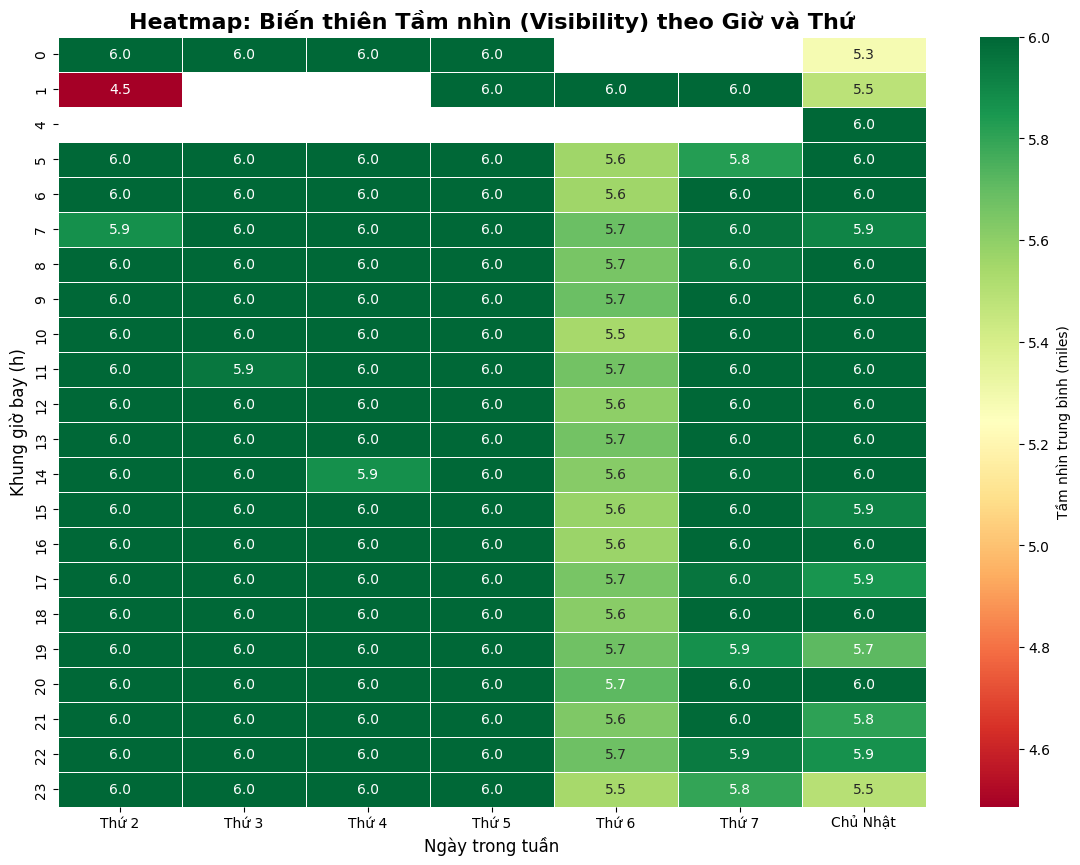

In [116]:
visibility_heatmap = df_train.groupby(['scheduled_hour', 'scheduled_dayofweek'])['visibility_miles'].mean().unstack()

# 2. Mapping lại nhãn ngày để khớp với dữ liệu thực tế (tránh lỗi Length mismatch)
day_map = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
visibility_heatmap = visibility_heatmap.rename(columns=day_map)

# 3. Vẽ biểu đồ
plt.figure(figsize=(14, 10))

# Sử dụng bảng màu RdYlGn (Red-Yellow-Green) 
# Màu Đỏ (Thấp) = Tầm nhìn kém (Nguy hiểm)
# Màu Xanh (Cao) = Tầm nhìn tốt (An toàn)
sns.heatmap(visibility_heatmap, 
            annot=True, 
            fmt=".1f", 
            cmap="RdYlGn", 
            linewidths=.5,
            cbar_kws={'label': 'Tầm nhìn trung bình (miles)'})

plt.title('Heatmap: Biến thiên Tầm nhìn (Visibility) theo Giờ và Thứ', fontsize=16, fontweight='bold')
plt.xlabel('Ngày trong tuần', fontsize=12)
plt.ylabel('Khung giờ bay (h)', fontsize=12)

plt.show()

- Tầm nhìn sụt giảm xuống mức 4.5 lúc 1h sáng, giải thích trực tiếp cho tỉ lệ trễ chuyến cao tại khung giờ này.

- Sự ổn định giữa tuần: Các ngày Thứ 2 (ban ngày), Thứ 3, Thứ 4 và Thứ 5 hầu như duy trì tầm nhìn hoàn hảo (6.0) xuyên suốt.

- Bất thường ngày Thứ 6: Đây là ngày duy nhất có tầm nhìn thấp hơn trung bình (5.5 - 5.7) trong toàn bộ các khung giờ, cho thấy điều kiện thời tiết kém lý tưởng kéo dài.

- Suy giảm đêm Chủ Nhật: Tầm nhìn có xu hướng giảm về cuối ngày (5.3 - 5.5), tạo áp lực lên các chuyến bay đêm muộn.

In [117]:
from scipy.stats import ttest_ind

low_vis = df_train[df_train['visibility_miles'] < 5]['delay_minutes']
high_vis = df_train[df_train['visibility_miles'] >= 5]['delay_minutes']

t_stat, p_val = ttest_ind(low_vis, high_vis, nan_policy='omit')
print(f"P-value: {p_val}")

P-value: 0.03937974162718394


**Nhận xét** Thực hiện T-test về việc `visibility_miles` có thật sự ảnh hưởng đến thời gian bay? 

-> Câu trả lời là có do P_value < 0.05

### So sánh biến mục tiêu với các biến thành phần

**So sánh `airline_code` với `label_delay`**

In [118]:
airline_check = df_train.groupby('airline_code').agg(
    total_flight=('label_delay', 'count'),
    delay_rate=('label_delay', 'mean')
).reset_index()

print(airline_check.sort_values(by='delay_rate', ascending=False))

  airline_code  total_flight  delay_rate
6           QH           163    0.024540
7           VJ          1314    0.019787
9           VU           126    0.015873
8           VN          1589    0.011328
2           9G           300    0.010000
0           0V             2    0.000000
1           3S             3    0.000000
3           BL           123    0.000000
4           CH            13    0.000000
5           HA             1    0.000000


In [124]:
def inspect_airlines_weather(df, airline_list):
    summary = []
    
    for code in airline_list:
        # Lọc dữ liệu theo hãng
        airline_df = df[df['airline_code'] == code]
        
        # Định nghĩa điều kiện thời tiết
        good_weather_mask = (airline_df['visibility_miles'] >= 5) & (airline_df['wind_speed_kt'] <= 10)
        
        # Tính toán tỷ lệ
        good_rate = airline_df[good_weather_mask]['label_delay'].mean() * 100
        bad_rate = airline_df[~good_weather_mask]['label_delay'].mean() * 100
        
        summary.append({
            'Hãng': code,
            'Trời ĐẸP (%)': round(good_rate, 2),
            'Trời XẤU (%)': round(bad_rate, 2),
            'Chênh lệch (%)': round(bad_rate - good_rate, 2)
        })
    
    return pd.DataFrame(summary)

# Chạy thử với 3 hãng lớn
airlines_to_check = ['VN', 'VJ', 'QH', 'VU']
comparison_df = inspect_airlines_weather(df_train, airlines_to_check)
print(comparison_df.to_markdown(index=False))

| Hãng   |   Trời ĐẸP (%) |   Trời XẤU (%) |   Chênh lệch (%) |
|:-------|---------------:|---------------:|-----------------:|
| VN     |           0.95 |           3.67 |             2.72 |
| VJ     |           1.53 |           9.33 |             7.8  |
| QH     |           2.56 |           0    |            -2.56 |
| VU     |           1.67 |           0    |            -1.67 |


- Ta thấy các hãng `VN` hay `VJ` thì khi gặp trời xấu tỉ lệ trễ chuyến bay tăng lên, `VJ` tăng rất mạnh khi thời tiết xấu

- Còn `QH` và `VU` có tỉ lệ trễ chuyến cao nhưng đề xuất phát từ khi trời đẹp. Có thể thấy các hãng này đa phần đều bị ảnh hưởng bởi cơ sở hã tầng, lịch bay nên mới gây ra chễ chuyến hoặc những sự cố không đáng có chứ không hẳn ảnh hưởng vì bị thời tiết xấu.

**Tỉ lệ trễ của 2 hãng `VN` và `VJ` theo xu hướng**

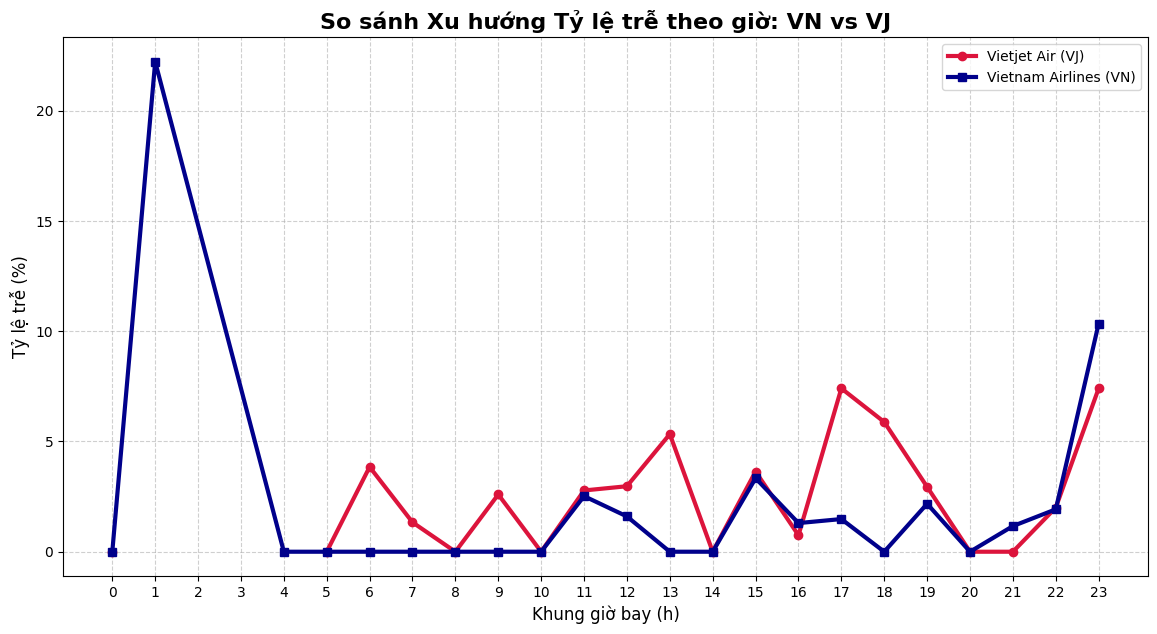

In [120]:
vj_vn_df = df_train[df_train['airline_code'].isin(['VJ', 'VN'])]

# 2. Tính tỷ lệ trễ theo giờ cho từng hãng
hourly_comparison = vj_vn_df.groupby(['scheduled_hour', 'airline_code'])['label_delay'].mean().unstack() * 100

# 3. Vẽ biểu đồ đường để thấy sự khác biệt về xu hướng
plt.figure(figsize=(14, 7))

# Vẽ đường cho VJ
plt.plot(hourly_comparison.index, hourly_comparison['VJ'], marker='o', linewidth=3, color='crimson', label='Vietjet Air (VJ)')
# Vẽ đường cho VN
plt.plot(hourly_comparison.index, hourly_comparison['VN'], marker='s', linewidth=3, color='darkblue', label='Vietnam Airlines (VN)')

# Thêm các chi tiết biểu đồ
plt.title('So sánh Xu hướng Tỷ lệ trễ theo giờ: VN vs VJ', fontsize=16, fontweight='bold')
plt.xlabel('Khung giờ bay (h)', fontsize=12)
plt.ylabel('Tỷ lệ trễ (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [125]:
night_flights = df_train[(df_train['scheduled_hour'] >= 12) & (df_train['scheduled_hour'] <= 23)]
vj_contribution = night_flights[night_flights['label_delay'] == 1]['airline_code'].value_counts(normalize=True) * 100

print("Tỷ lệ đóng góp vào các ca trễ từ 12h-18h:")
print(vj_contribution)

Tỷ lệ đóng góp vào các ca trễ từ 12h-18h:
airline_code
VJ    51.219512
VN    31.707317
9G     7.317073
QH     4.878049
VU     4.878049
Name: proportion, dtype: float64


**Nhận xét:** Điều này cho thấy rõ số chuyến trễ của hãng `VJ` ảnh hưởng rất lớn đối với tỉ lệ trễ theo xu hướng chung. Đa phần sẽ là do thời tiết xấu cộng với việc sắp xếp lịch, sự trễ theo dây chuyền và việc có quá nhiều lịch bay khiến cho hãng `VJ` bị quá tải dẫn đến trễ nhiều.